# WORD GRAPH

In [ ]:
pip install --upgrade pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 46.4 MB/s eta 0:00:00


In [ ]:
%cd /content/drive/MyDrive/PPW

[Errno 2] No such file or directory: '/content/drive/MyDrive/PPW'
/content


In [ ]:
import pymupdf

doc = pymupdf.open("main.pdf") # open a document
out = open("output.txt", "wb") # create a text output
for page in doc: # iterate the document pages
    text = page.get_text().encode("utf8") # get plain text (is in UTF-8)
    out.write(text) # write text of page
    out.write(bytes((12,))) # write page delimiter (form feed 0x0C)
out.close()

In [ ]:
%%capture
!pip install nltk

In [ ]:
import nltk
nltk.download('punkt')  # hanya perlu sekali
nltk.download('punkt_tab')  # opsional, untuk versi terbaru NLTK (≥3.8.2)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
with open('output.txt', 'r', encoding='utf-8') as file:
    teks = file.read()

print(teks[:200])  # tampilkan 200 karakter pertama

3043 
Jurnal Indonesia : Manajemen Informatika dan Komunikasi (JIMIK) 
 Vol. 5 No. 3 (2024) 
 
 
 
 
 
 
 
 
 
 
 
 
 
https://journal.stmiki.ac.id 
E-
  P-
 
 
 
Analisis Sentimen Publik Terhadap Pen


In [ ]:
# Install: pip install nltk
import nltk


sentences = nltk.sent_tokenize(teks)
print(sentences)

['3043 \nJurnal Indonesia : Manajemen Informatika dan Komunikasi (JIMIK) \n Vol.', '5 No.', '3 (2024) \n \n \n \n \n \n \n \n \n \n \n \n \n \nhttps://journal.stmiki.ac.id \nE-\n  P-\n \n \n \nAnalisis Sentimen Publik Terhadap Penurunan Jumlah \nPernikahan di Indonesia menggunakan Algoritma K-Nearest \nNeighbors (KNN) \n \nAfyra Ar’bah Lailany 1, Sri Lestari 2* \n \n1,2* Program Studi Sistem Informasi, Sekolah Tinggi Ilmu Komputer Cipta Karya Informatika, Kota Jakarta \nTimur, Daerah Khusus Ibukota Jakarta, Indonesia.', 'Email: afyraarbah@gmail.com 1, sri.lestari1203@gmail.com 2* \n \nHistori Artikel:  \nDikirim 25 Juli 2024; Diterima dalam bentuk revisi 10 Agustus 2024; Diterima 20 Agustus 2024; Diterbitkan 20 \nSeptember 2024.', 'Semua hak dilindungi oleh Lembaga Penelitian dan Pengabdian Masyarakat (LPPM) STMIK \nIndonesia Banda Aceh.', 'Abstrak \nPernikahan di Indonesia adalah aspek penting dalam budaya dan masyarakatnya.', 'Namun, dalam beberapa tahun \nterakhir, telah terjadi pen

In [ ]:
import pandas as pd
df = pd.DataFrame(sentences, columns=['kalimat'])
print(df)

                                               kalimat
0    3043 \nJurnal Indonesia : Manajemen Informatik...
1                                                5 No.
2    3 (2024) \n \n \n \n \n \n \n \n \n \n \n \n \...
3    Email: afyraarbah@gmail.com 1, sri.lestari1203...
4    Semua hak dilindungi oleh Lembaga Penelitian d...
..                                                 ...
275                Jurnal \nStudi Pemuda, 9(2), 77-89.
276                              Widiyanto, H. (2020).
277  Konsep pernikahan dalam Islam (Studi fenomenol...
278       Jurnal \nIslam \nNusantara, 4(1), \n103-110.
279  DOI: \nhttps://doi.org/10.33852/jurnalin.v4i1....

[280 rows x 1 columns]


In [ ]:
df.to_csv('kalimat.csv', index=False, encoding='utf-8')

Untuk membuat word graph

Lanjutkan dengan menggunakan https://www.geeksforgeeks.org/nlp/co-occurence-matrix-in-nlp/

In [ ]:
import pandas as pd

# 1. Read the 'kalimat.csv' file into a pandas DataFrame.
df_kalimat = pd.read_csv('kalimat.csv')

# 2. Access the 'kalimat' column and 3. Concatenate all text entries into a single string.
all_text = df_kalimat['kalimat'].str.cat(sep=' ')

print(f"First 500 characters of the concatenated text:\n{all_text[:500]}")

First 500 characters of the concatenated text:
3043 
Jurnal Indonesia : Manajemen Informatika dan Komunikasi (JIMIK) 
 Vol. 5 No. 3 (2024) 
 
 
 
 
 
 
 
 
 
 
 
 
 
https://journal.stmiki.ac.id 
E-
  P-
 
 
 
Analisis Sentimen Publik Terhadap Penurunan Jumlah 
Pernikahan di Indonesia menggunakan Algoritma K-Nearest 
Neighbors (KNN) 
 
Afyra Ar’bah Lailany 1, Sri Lestari 2* 
 
1,2* Program Studi Sistem Informasi, Sekolah Tinggi Ilmu Komputer Cipta Karya Informatika, Kota Jakarta 
Timur, Daerah Khusus Ibukota Jakarta, Indonesia. Email: afyraa


In [ ]:
import re
import string
import pandas as pd

df_to_clean = pd.read_csv('kalimat.csv')

def clean_text(text):
    # Pastikan input string
    if not isinstance(text, str):
        return ""

    # Hapus karakter spesifik
    text = text.replace('◼', '')

    # Deteksi kata berulang seperti "laki-laki", "pura-pura"
    # Pola: kata-kata yang sama dipisah tanda hubung
    text = re.sub(r'\b(\w+)-\1\b', r'\1', text)

    # Hapus punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Hapus angka
    text = re.sub(r'\d+', '', text)

    # Lowercase
    text = text.lower()

    # Hapus kata yang hanya satu huruf (mis. "v", "a", "b")
    text = re.sub(r'\b[a-zA-Z]\b', ' ', text)

    # Hilangkan spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    # --- Tambahan: hapus kata berulang berurutan + filter 1 huruf lagi (jaga-jaga) ---
    if text:
        tokens = text.split()

        cleaned_tokens = []
        prev = None
        for tok in tokens:
            # skip kalau hanya satu huruf
            if len(tok) == 1:
                continue
            # skip kalau sama dengan kata sebelumnya (kata berulang)
            if tok == prev:
                continue
            cleaned_tokens.append(tok)
            prev = tok

        text = " ".join(cleaned_tokens)
    # ----------------------------------------------------------------------

    return text

# Terapkan pembersihan
df_to_clean['cleaned_kalimat'] = df_to_clean['kalimat'].apply(clean_text)

# Simpan ke CSV
df_to_clean.to_csv('kalimat_cleaned.csv', index=False, encoding='utf-8')

print("Processed data with cleaned text saved to 'kalimat_cleaned.csv'")
print(df_to_clean[['kalimat', 'cleaned_kalimat']].head())

Processed data with cleaned text saved to 'kalimat_cleaned.csv'
                                                                                                                                                                                                                                                                                                                                                                                                                                          kalimat  \
0                                                                                                                                                                                                                                                                                                                                                                  3043 \nJurnal Indonesia : Manajemen Informatika dan Komunikasi (JIMIK) \n Vol.   
1                                                             

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import defaultdict, Counter
import numpy as np
import pandas as pd

nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('indonesian'))

# Filter kata non-alfanumerik dan hapus stopwords
words = [word for word in words if word.isalnum() and word not in stop_words]

window_size = 3  # Meningkatkan ukuran jendela untuk hubungan kata yang lebih kaya

# 6. Membuat daftar pasangan kata yang muncul bersamaan
co_occurrences = defaultdict(Counter)
for i, word in enumerate(words):
    for j in range(max(0, i - window_size), min(len(words), i + window_size + 1)):
        if i != j:
            co_occurrences[word][words[j]] += 1

# 7. Membuat daftar kata unik
unique_words = list(set(words))

# 8. Inisialisasi matriks ko-okurensi
co_matrix = np.zeros((len(unique_words), len(unique_words)), dtype=int)

# 9. Membuat mapping dari kata ke indeks
word_index = {word: idx for idx, word in enumerate(unique_words)}

# 10. Mengisi matriks ko-okurensi
for word, neighbors in co_occurrences.items():
    for neighbor, count in neighbors.items():
        if neighbor in word_index:  # Pastikan kata tetangga ada dalam unique_words
            co_matrix[word_index[word]][word_index[neighbor]] = count

# 11. Membuat DataFrame agar lebih mudah dibaca
co_matrix_df = pd.DataFrame(co_matrix, index=unique_words, columns=unique_words)

# Menampilkan matriks ko-okurensi
print("Matriks Ko-okurensi")
print(co_matrix_df.iloc[:10, :10])
print("Total kata setelah preprocessing:", len(words))


Matriks Ko-okurensi
             informatika  dihalaman  berkurang  menganggap  diprediksi  3050  \
informatika            0          0          0           0           0     0   
dihalaman              0          0          0           0           0     0   
berkurang              0          0          0           0           0     0   
menganggap             0          0          0           0           0     0   
diprediksi             0          0          0           0           0     0   
3050                   0          0          0           0           0     0   
pilihan                0          0          0           1           0     0   
finansial              0          0          0           0           0     0   
aims                   0          0          0           0           0     0   
memisahkan             0          0          0           0           0     0   

             pilihan  finansial  aims  memisahkan  
informatika        0          0     0          

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


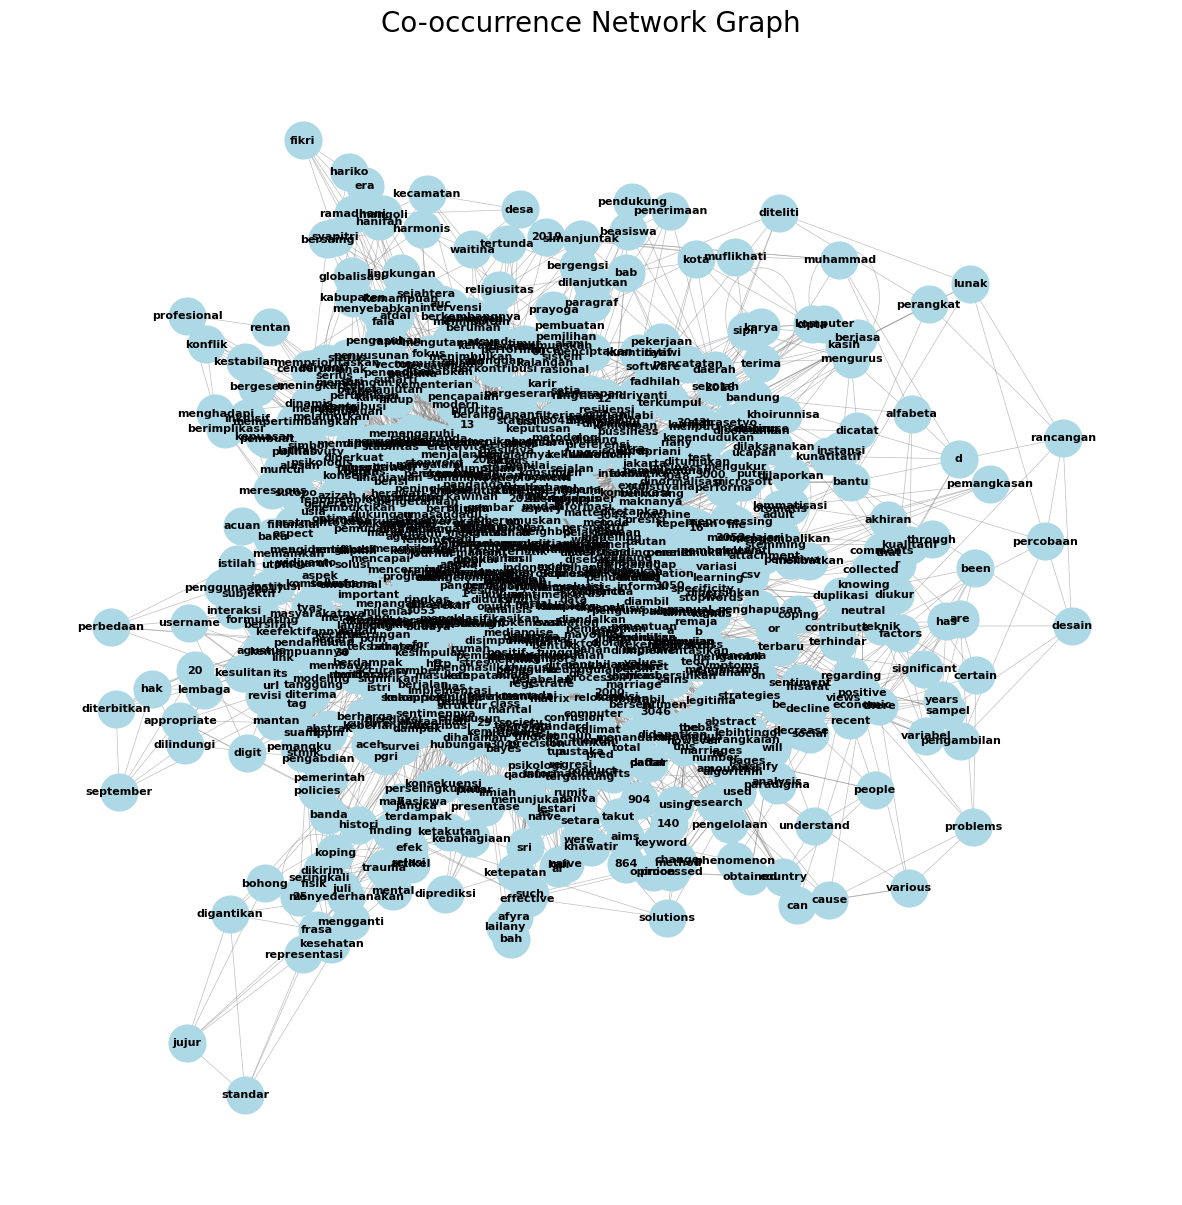

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.from_pandas_adjacency(co_matrix_df)

# Visualize the graph
plt.figure(figsize=(15, 15))
pos = nx.spring_layout(G, k=0.15, iterations=20) # positions for all nodes - k regulates the distance between nodes
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightblue')
nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.5, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

plt.title("Co-occurrence Network Graph", size=20)
plt.axis('off') # Hide axes
plt.show()


In [ ]:
pagerank_scores = nx.pagerank(G)
print("Hasil perhitungan PageRank untuk tiap node:")
for node, score in sorted(pagerank_scores.items(), key=lambda item: item[1], reverse=True)[:10]:
    print(f"{node}: {score:.4f}")

Hasil perhitungan PageRank untuk tiap node:
data: 0.0288
pernikahan: 0.0184
sentimen: 0.0124
penelitian: 0.0122
indonesia: 0.0121
jurnal: 0.0110
penurunan: 0.0101
proses: 0.0085
algoritma: 0.0082
knn: 0.0079


In [ ]:
 import pandas as pd

# 1. Membuat DataFrame pandas dari dictionary pagerank_scores
pagerank_df = pd.DataFrame(list(pagerank_scores.items()), columns=['Kata', 'Skor PageRank'])

# 2. Mengurutkan DataFrame berdasarkan 'Skor PageRank' secara menurun
pagerank_df = pagerank_df.sort_values(by='Skor PageRank', ascending=False)

# 3. Menampilkan 20 kata teratas dari DataFrame yang sudah diurutkan
print("20 kata dengan Skor PageRank tertinggi:")
print(pagerank_df.head(20).reset_index(drop=True))


20 kata dengan Skor PageRank tertinggi:
          Kata  Skor PageRank
0         data       0.028801
1   pernikahan       0.018369
2     sentimen       0.012386
3   penelitian       0.012186
4    indonesia       0.012106
5       jurnal       0.010968
6    penurunan       0.010071
7       proses       0.008495
8    algoritma       0.008181
9          knn       0.007857
10  masyarakat       0.007759
11      sosial       0.007604
12    keluarga       0.007261
13           3       0.007247
14       hasil       0.006960
15       https       0.006559
16       tahap       0.006139
17         the       0.005549
18    analisis       0.005546
19        2024       0.005333


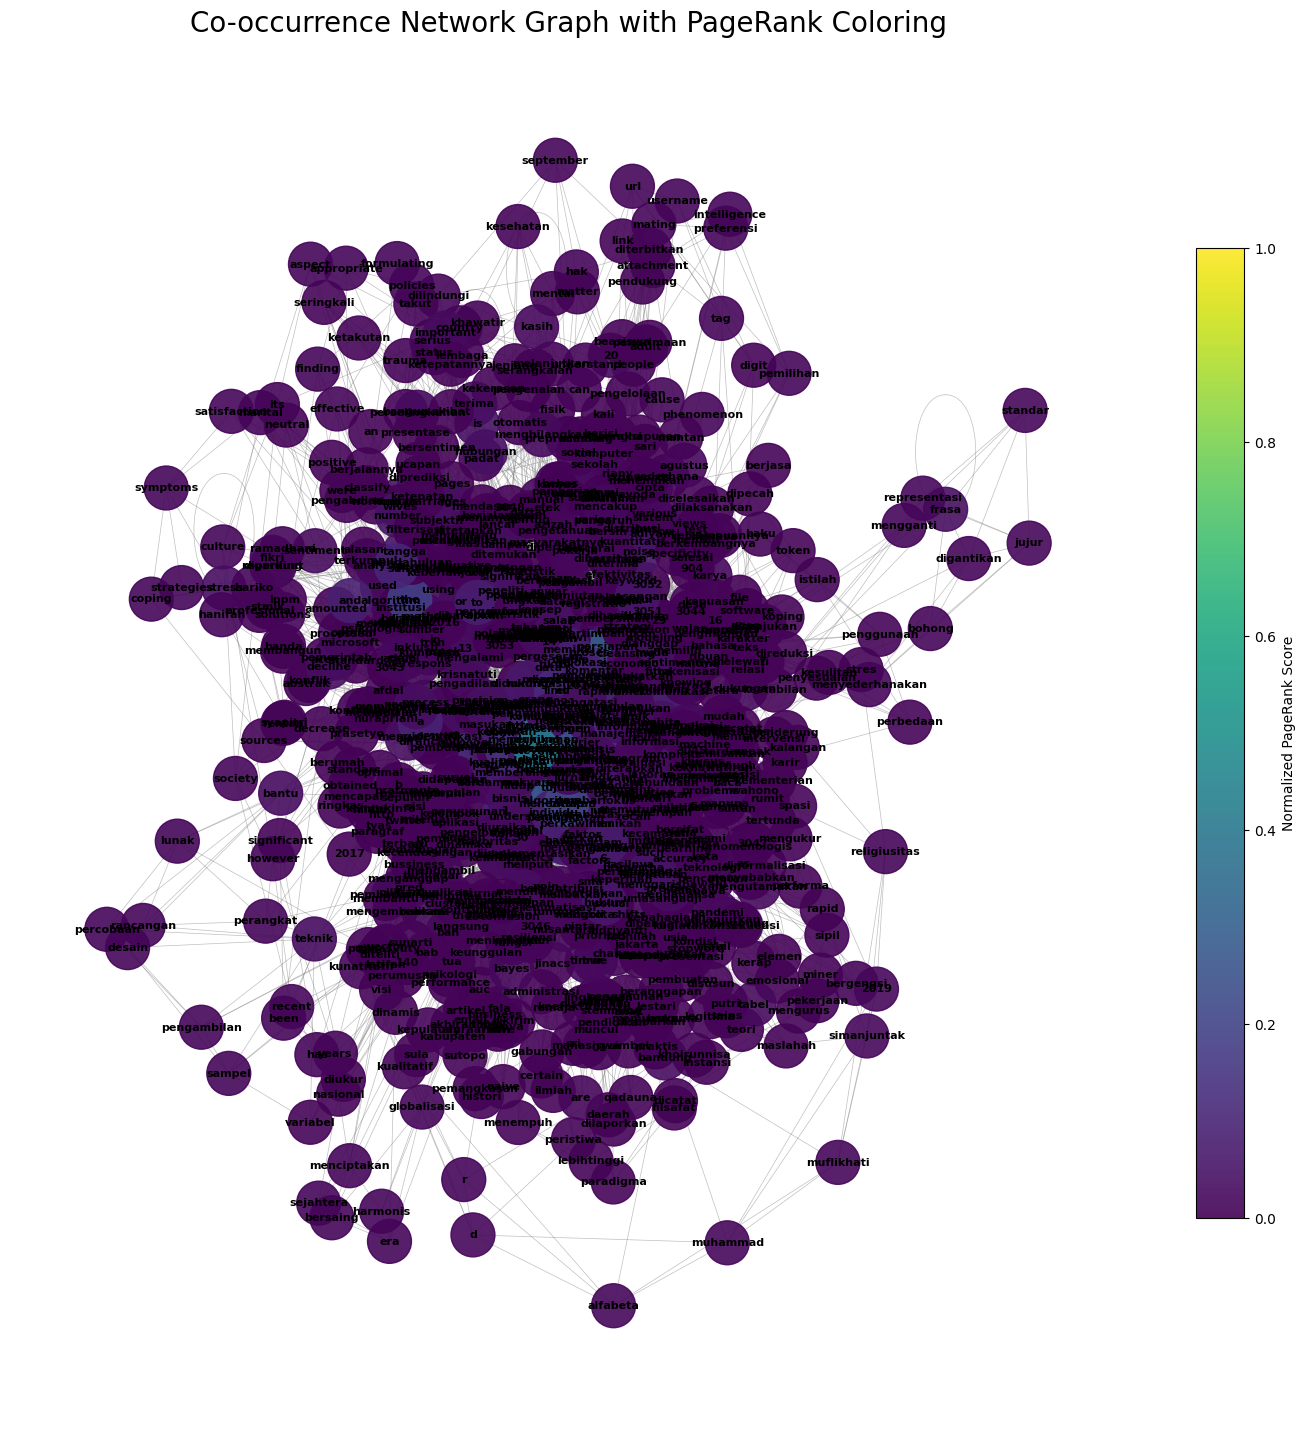

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Get PageRank scores from the previously calculated pagerank_scores dictionary
pagerank_values = list(pagerank_scores.values())

# Normalize PageRank scores for coloring (0 to 1 range)
# Avoid division by zero if all scores are the same or zero
if len(set(pagerank_values)) > 1:
    scores_norm = (pagerank_values - np.min(pagerank_values)) / (np.max(pagerank_values) - np.min(pagerank_values))
else:
    scores_norm = np.zeros_like(pagerank_values) # If all scores are same, set to 0

node_colors = [scores_norm[list(pagerank_scores.keys()).index(node)] for node in G.nodes()]

plt.figure(figsize=(18, 18))
pos = nx.spring_layout(G, k=0.15, iterations=20)

# Draw nodes with colors based on PageRank score
nodes = nx.draw_networkx_nodes(G, pos, node_size=1000, node_color=node_colors, cmap=plt.cm.viridis, alpha=0.9)
nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.5, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

plt.title("Co-occurrence Network Graph with PageRank Coloring", size=20)
plt.axis('off')

# Add a color bar to show PageRank scale
cbar = plt.colorbar(nodes, shrink=0.7)
cbar.set_label('Normalized PageRank Score')

plt.show()